# Pavan S (24BAD085)

# NMF Recommendation System

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

In [5]:
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
df = pd.read_csv(url, sep='\t', names=['user_id','item_id','rating','timestamp'])

In [6]:
user_item = df.pivot(index='user_id', columns='item_id', values='rating')
matrix = user_item.fillna(0)

In [7]:
model = NMF(n_components=20, random_state=42)
W = model.fit_transform(matrix)
H = model.components_

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [8]:
reconstructed = np.dot(W, H)
reconstructed_df = pd.DataFrame(reconstructed, index=user_item.index, columns=user_item.columns)

In [10]:
actual = user_item.values
predicted = reconstructed_df.values

mask = ~np.isnan(actual)

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
print("RMSE:", rmse)

RMSE: 2.2307029724506435


In [11]:
def recommend(user_id, n=5):
    user_ratings = reconstructed_df.loc[user_id]
    original = user_item.loc[user_id]
    unseen = original[original.isna()]
    recs = user_ratings[unseen.index].sort_values(ascending=False)
    return recs.head(n)

print(recommend(1))

item_id
318    3.658503
408    3.640533
475    3.607864
655    3.572531
433    3.558239
Name: 1, dtype: float64


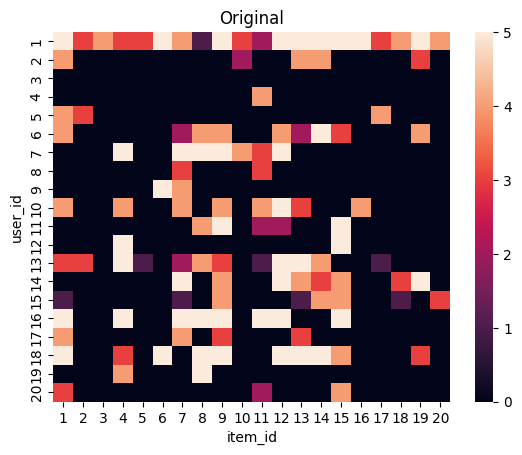

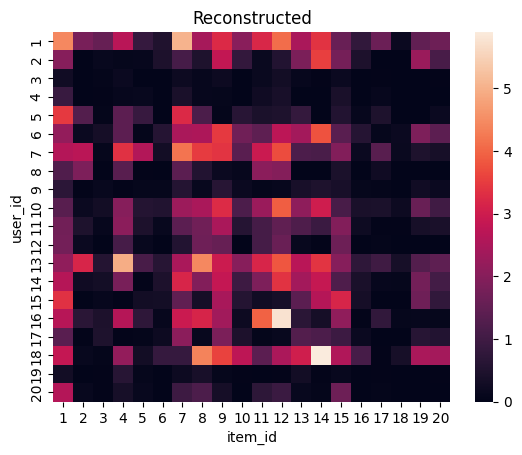

In [12]:
plt.figure()
sns.heatmap(matrix.iloc[:20,:20])
plt.title("Original")
plt.show()

plt.figure()
sns.heatmap(reconstructed_df.iloc[:20,:20])
plt.title("Reconstructed")
plt.show()